In [83]:
import torch
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
import torch.nn as nn
from sklearn.datasets import make_circles
import matplotlib.pyplot as plt
print(torch.__version__)

2.13.0+cpu


In [84]:
n_samples = 1000

X, y = make_circles(n_samples, noise=0.03, random_state=42)

X = torch.from_numpy(X).type(torch.float)
y = torch.from_numpy(y).type(torch.float)

In [85]:
X

tensor([[ 0.7542,  0.2315],
        [-0.7562,  0.1533],
        [-0.8154,  0.1733],
        ...,
        [-0.1369, -0.8100],
        [ 0.6704, -0.7675],
        [ 0.2811,  0.9638]])

In [86]:
print(f"First 5 samples of X: {X[:5]}")
print(f"First 5 samples of y: {y[:5]}")

First 5 samples of X: tensor([[ 0.7542,  0.2315],
        [-0.7562,  0.1533],
        [-0.8154,  0.1733],
        [-0.3937,  0.6929],
        [ 0.4422, -0.8967]])
First 5 samples of y: tensor([1., 1., 1., 1., 0.])


In [87]:
X.shape

torch.Size([1000, 2])

In [88]:
circles = pd.DataFrame({"X1": X[:, 0],
                        "X2": X[:, 1],
                        "label": y
    })

circles.head()

,X1,X2,label
0,0.754246,0.231481,1.0
1,-0.756159,0.153259,1.0
2,-0.815392,0.173282,1.0
3,-0.393731,0.692883,1.0
4,0.442208,-0.896723,0.0


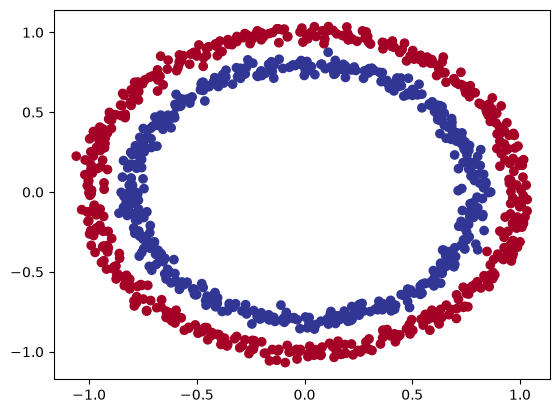

In [89]:
plt.scatter(x=X[:,0], y=X[:,1], c=y, cmap=plt.cm.RdYlBu)

In [90]:
type(X), type(y), X.dtype, y.dtype

(torch.Tensor, torch.Tensor, torch.float32, torch.float32)

In [91]:
torch.manual_seed(42)

In [92]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [93]:
len(X_train), len(X_test), len(y_train), len(y_test)

(800, 200, 800, 200)

In [94]:
class CircleModelV0(nn.Module):
    def __init__(self):
        super().__init__()

        self.sequential = nn.Sequential(
            nn.Linear(in_features=2, out_features=5),
            nn.Linear(in_features=5, out_features=1)
        )

    def forward(self, x):
        return self.sequential(x)

model_0 = CircleModelV0()
model_0

CircleModelV0(
  (sequential): Sequential(
    (0): Linear(in_features=2, out_features=5, bias=True)
    (1): Linear(in_features=5, out_features=1, bias=True)
  )
)

In [95]:
model_0.state_dict()

OrderedDict([('sequential.0.weight',
              tensor([[ 0.5406,  0.5869],
                      [-0.1657,  0.6496],
                      [-0.1549,  0.1427],
                      [-0.3443,  0.4153],
                      [ 0.6233, -0.5188]])),
             ('sequential.0.bias',
              tensor([0.6146, 0.1323, 0.5224, 0.0958, 0.3410])),
             ('sequential.1.weight',
              tensor([[-0.0631,  0.3448,  0.0661, -0.2088,  0.1140]])),
             ('sequential.1.bias', tensor([-0.2060]))])

In [96]:
loss_fn = nn.BCEWithLogitsLoss()

optimizer = torch.optim.SGD(params=model_0.parameters(), lr=0.001)

In [97]:
def accuracy_fn(y_true, y_pred):
    correct = torch.eq(y_true, y_pred).sum().item()
    acc = (correct/len(y_pred))*100
    return acc

In [98]:
X_train

tensor([[ 0.6122,  0.5094],
        [ 0.2866,  0.9797],
        [ 0.6366, -0.7858],
        ...,
        [-0.3245, -0.9184],
        [ 0.9710, -0.3082],
        [ 0.2985, -0.9833]])

In [99]:
epochs = 100

for epoch in range(epochs):
    model_0.train()

    y_logits = model_0(X_train).squeeze()
    y_pred = torch.round(torch.sigmoid(y_logits))

    loss = loss_fn(y_logits, y_train)

    acc = accuracy_fn(y_true=y_train, y_pred=y_pred)

    optimizer.zero_grad()

    loss.backward()

    optimizer.step()

    model_0.eval()
    with torch.inference_mode():
        test_logits = model_0(X_test).squeeze()
        test_pred = torch.round(torch.sigmoid(test_logits))

        test_loss = loss_fn(test_logits, y_test)
        test_acc = accuracy_fn(y_true=y_test, y_pred=test_pred)

    if epoch % 10 == 0:
        print(f"Epoch: {epoch} | Loss: {loss:.5f}, Acc: {acc:.2f}% | Test loss: {test_loss:.5f} | Test acc: {test_acc:.2f}%")

Epoch: 0 | Loss: 0.69579, Acc: 49.88% | Test loss: 0.69698 | Test acc: 50.50%
Epoch: 10 | Loss: 0.69576, Acc: 49.88% | Test loss: 0.69697 | Test acc: 50.50%
Epoch: 20 | Loss: 0.69574, Acc: 49.88% | Test loss: 0.69695 | Test acc: 50.50%
Epoch: 30 | Loss: 0.69571, Acc: 49.88% | Test loss: 0.69693 | Test acc: 50.50%
Epoch: 40 | Loss: 0.69568, Acc: 49.88% | Test loss: 0.69692 | Test acc: 50.50%
Epoch: 50 | Loss: 0.69566, Acc: 49.88% | Test loss: 0.69690 | Test acc: 50.50%
Epoch: 60 | Loss: 0.69563, Acc: 49.88% | Test loss: 0.69689 | Test acc: 50.50%
Epoch: 70 | Loss: 0.69560, Acc: 49.88% | Test loss: 0.69687 | Test acc: 50.50%
Epoch: 80 | Loss: 0.69558, Acc: 49.88% | Test loss: 0.69686 | Test acc: 50.50%
Epoch: 90 | Loss: 0.69555, Acc: 49.88% | Test loss: 0.69684 | Test acc: 50.50%


In [100]:
model_0.eval()
with torch.inference_mode():
    y_logits = model_0(X_test)[:5]

y_logits

tensor([[-0.1887],
        [-0.0727],
        [-0.1720],
        [-0.0891],
        [-0.1466]])

In [109]:
class CircleModel2(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer_1 = nn.Linear(2, 10)
        self.layer_2 = nn.Linear(10, 10)
        self.layer_3 = nn.Linear(10, 1)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.layer_1(x)
        x = self.relu(x)

        x = self.layer_2(x)
        x = self.relu(x)

        x = self.layer_3(x)

        return x

In [110]:
modelV2 = CircleModel2()

In [111]:
loss_fn2 = nn.BCEWithLogitsLoss()
optimizer = torch.optim.SGD(
    modelV2.parameters(),
    lr=0.1
)

In [112]:
for epoch in range(1000):

    y_logits = modelV2(X).squeeze()

    loss = loss_fn2(y_logits, y)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    modelV2.eval()
    with torch.inference_mode():
        y_logits = modelV2(X).squeeze()

        y_pred_prob = torch.sigmoid(y_logits)

        y_pred = torch.round(y_pred_prob)

        accuracy = (y_pred == y).float().mean()*100

        if epoch % 100 == 0:
            print(f"Epoch: {epoch} | Loss: {loss:.4f} | Accuracy: {accuracy:.2f}%")


Epoch: 0 | Loss: 0.6932 | Accuracy: 50.00%
Epoch: 100 | Loss: 0.6895 | Accuracy: 64.20%
Epoch: 200 | Loss: 0.6853 | Accuracy: 78.50%
Epoch: 300 | Loss: 0.6802 | Accuracy: 76.70%
Epoch: 400 | Loss: 0.6725 | Accuracy: 73.40%
Epoch: 500 | Loss: 0.6600 | Accuracy: 77.20%
Epoch: 600 | Loss: 0.6380 | Accuracy: 87.10%
Epoch: 700 | Loss: 0.5973 | Accuracy: 93.80%
Epoch: 800 | Loss: 0.5243 | Accuracy: 95.80%
Epoch: 900 | Loss: 0.4137 | Accuracy: 96.80%


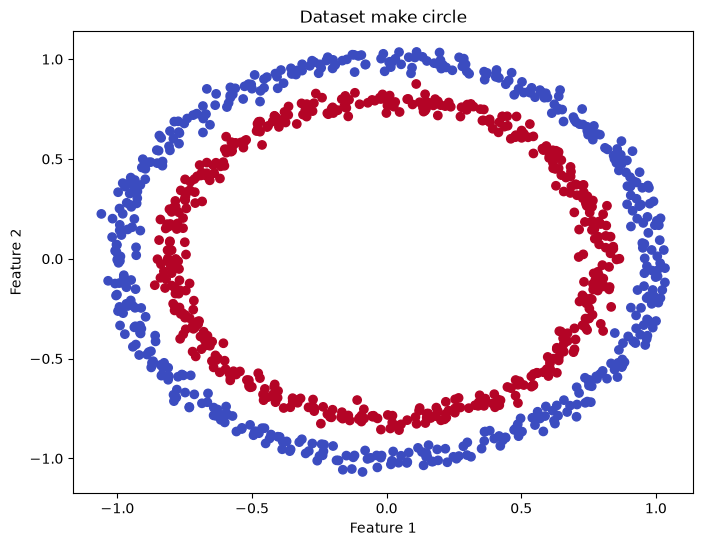

In [113]:
plt.figure(figsize=(8, 6))

plt.scatter(X[:, 0], X[:, 1], c=y, cmap="coolwarm")

plt.title("Dataset make circle")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")

plt.show()

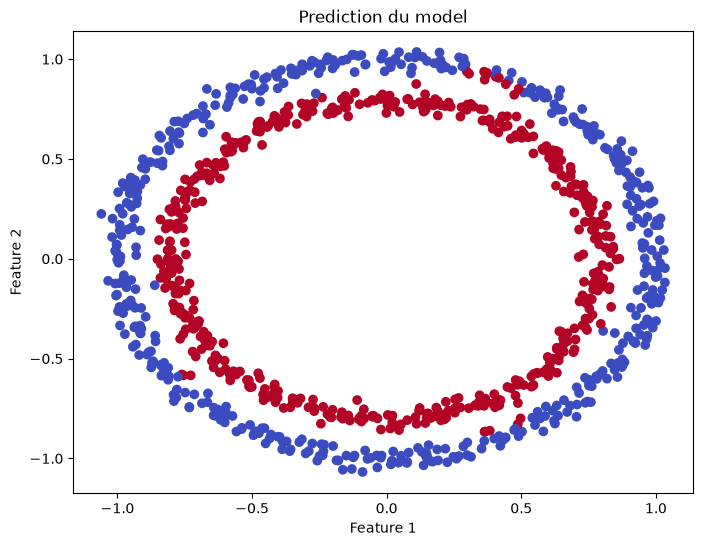

In [114]:
modelV2.eval()
with torch.inference_mode():
    logits = modelV2(X).squeeze()

    predictions = torch.round(torch.sigmoid(logits))

    plt.figure(figsize=(8, 6))
    plt.scatter(
        X[:,0],
        X[:,1],
        c=predictions,
        cmap='coolwarm'
    )

    plt.title("Prediction du model")
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")

    plt.show()





In [115]:
# Z = np.array([-10, -9, -8,-7,-6,-5,-4,-3,-2,-1,1,2,3,4,5,6,7,8,9])
A = torch.arange(-10, 10)
A

tensor([-10,  -9,  -8,  -7,  -6,  -5,  -4,  -3,  -2,  -1,   0,   1,   2,   3,
          4,   5,   6,   7,   8,   9])

In [116]:
def relu(x: torch.Tensor) -> torch.Tensor:
    return torch.maximum(torch.tensor(0), x)

relu(A)

tensor([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 2, 3, 4, 5, 6, 7, 8, 9])

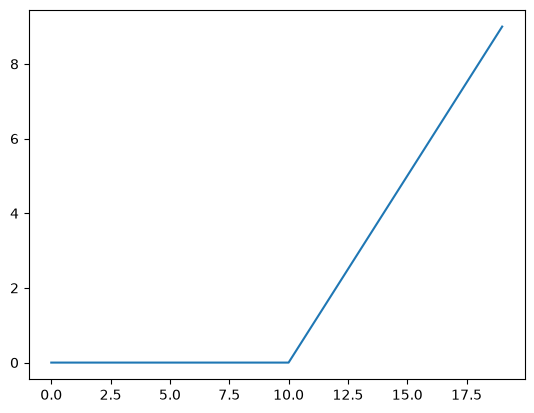

In [117]:
plt.plot(relu(A))

In [118]:
def sigmoid(x):
    return 1/ (1 + torch.exp(-x))

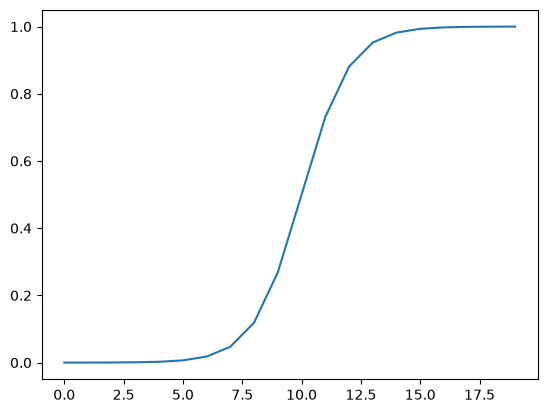

In [119]:
plt.plot(torch.sigmoid(A))

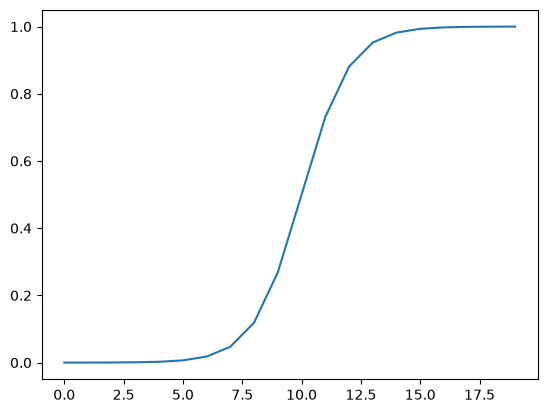

In [120]:
plt.plot(sigmoid(A))

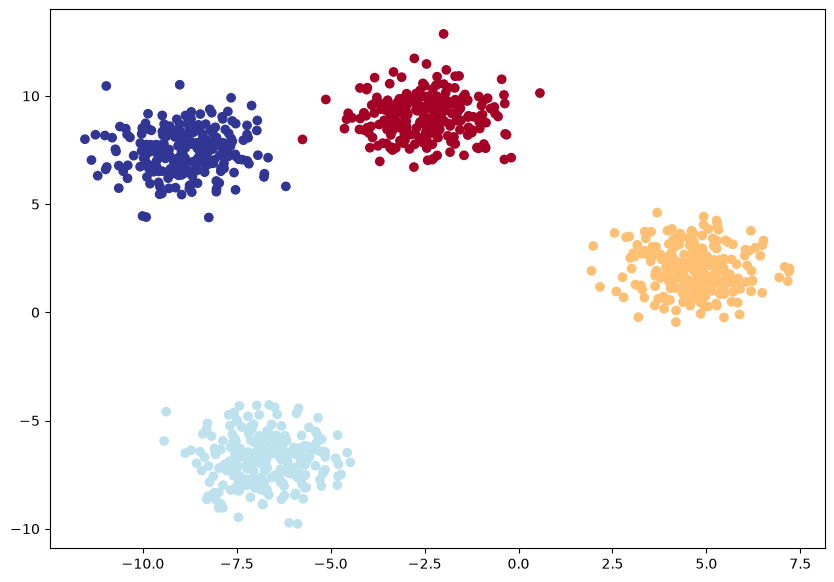

In [127]:
from sklearn.datasets import make_blobs

# set the hyperparameters for data creation
NUM_CLASSES = 4
NUM_FEATURES = 2
RANDOM_SEED = 42

X_blob, y_blob = make_blobs(
    n_samples=1000,
    n_features=NUM_FEATURES,
    centers=NUM_CLASSES,
    random_state=RANDOM_SEED
)

X_blob = torch.from_numpy(X_blob).type(torch.float)
y_blob = torch.from_numpy(y_blob).type(torch.LongTensor)

X_blob_train, X_blob_test, y_blob_train, y_blob_test = train_test_split(
    X_blob,
    y_blob,
    test_size=0.2,
    random_state=RANDOM_SEED
)

plt.figure(figsize=(10, 7))
plt.scatter(X_blob[:,0], X_blob[:,1], c=y_blob, cmap=plt.cm.RdYlBu)

In [128]:
class BlobModel(nn.Module):
    def __init__(self, input_features, output_feature, hidden_units=8):
        super().__init__()

        self.linear_layer_stack = nn.Sequential(
            nn.Linear(in_features=input_features, out_features=hidden_units),
            nn.ReLU(),
            nn.Linear(in_features=hidden_units, out_features=hidden_units),
            nn.ReLU(),
            nn.Linear(in_features=hidden_units, out_features=output_feature)
        )

    def forward(self, x):
        return self.linear_layer_stack(x)
        



In [129]:
model_4 = BlobModel(
    input_features=2,
    output_feature=4,
    hidden_units=8
)

In [130]:
X_blob_train.shape, y_blob_train[:5]

(torch.Size([800, 2]), tensor([1, 0, 2, 2, 0]))

In [131]:
loss_fn = nn.CrossEntropyLoss()

optimizer = torch.optim.SGD(params=model_4.parameters(), lr=0.1)

In [132]:
X_blob_train

tensor([[ 4.9069,  2.8628],
        [-2.5863,  9.3554],
        [-7.9759, -8.3202],
        ...,
        [-1.9942,  9.5281],
        [-6.8358, -7.0271],
        [-8.9669,  5.4417]])

In [135]:
torch.manual_seed(42)

epochs = 100

for epoch in range(epochs):
    model_4.train()

    y_logits = model_4(X_blob_train)
    y_pred = torch.softmax(y_logits, dim=1).argmax(dim=1)

    loss = loss_fn(y_logits, y_blob_train)
    acc = accuracy_fn(y_true=y_blob_train, y_pred=y_pred)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    model_4.eval()
    with torch.inference_mode():
        test_logits = model_4(X_blob_test)
        test_preds = torch.softmax(test_logits, dim=1).argmax(dim=1)
        print(test_logits.shape, y_blob_test.shape)
        test_loss = loss_fn(test_logits, y_blob_test)
        test_acc = accuracy_fn(y_true=y_blob_test, y_pred=test_preds)

    if epoch % 10 == 0:
        print(f"Epoch: {epoch} | Loss: {loss:.4f} | Acc: {acc:.2f} | Test loss: {test_loss:.4f} | Test Acc: {test_acc:.2f}")

torch.Size([200, 4]) torch.Size([200])
Epoch: 0 | Loss: 0.9665 | Acc: 57.38 | Test loss: 0.9266 | Test Acc: 62.00
torch.Size([200, 4]) torch.Size([200])
torch.Size([200, 4]) torch.Size([200])
torch.Size([200, 4]) torch.Size([200])
torch.Size([200, 4]) torch.Size([200])
torch.Size([200, 4]) torch.Size([200])
torch.Size([200, 4]) torch.Size([200])
torch.Size([200, 4]) torch.Size([200])
torch.Size([200, 4]) torch.Size([200])
torch.Size([200, 4]) torch.Size([200])
torch.Size([200, 4]) torch.Size([200])
Epoch: 10 | Loss: 0.5751 | Acc: 99.25 | Test loss: 0.5899 | Test Acc: 100.00
torch.Size([200, 4]) torch.Size([200])
torch.Size([200, 4]) torch.Size([200])
torch.Size([200, 4]) torch.Size([200])
torch.Size([200, 4]) torch.Size([200])
torch.Size([200, 4]) torch.Size([200])
torch.Size([200, 4]) torch.Size([200])
torch.Size([200, 4]) torch.Size([200])
torch.Size([200, 4]) torch.Size([200])
torch.Size([200, 4]) torch.Size([200])
torch.Size([200, 4]) torch.Size([200])
Epoch: 20 | Loss: 0.3486 | Ac

In [136]:
# Make predictions
model_4.eval()
with torch.inference_mode():
    y_logits = model_4(X_blob_test)

y_logits[:10]

tensor([[-1.1258,  5.4098, -6.4020, -7.4302],
        [-2.4225, -6.1861, -3.5701,  3.1369],
        [-3.2810, -3.7906,  3.1715, -2.6533],
        [-1.1829,  4.0773, -4.0018, -5.0993],
        [ 3.3694, -1.9812, -7.7389, -5.8946],
        [-2.8557, -6.9401, -3.9433,  3.5631],
        [-3.0329, -3.4249,  2.8975, -2.3042],
        [ 3.0811, -3.6868, -6.3969, -3.6536],
        [-3.9198, -4.5004,  3.6219, -3.1772],
        [ 3.1674, -3.0429, -6.7833, -4.4155]])

In [137]:
y_pred_probs = torch.softmax(y_logits, dim=1)
y_pred_probs[:10]

tensor([[1.4488e-03, 9.9854e-01, 7.4058e-06, 2.6488e-06],
        [3.8311e-03, 8.8882e-05, 1.2160e-03, 9.9486e-01],
        [1.5679e-03, 9.4189e-04, 9.9455e-01, 2.9373e-03],
        [5.1650e-03, 9.9442e-01, 3.0820e-04, 1.0285e-04],
        [9.9517e-01, 4.7221e-03, 1.4914e-05, 9.4314e-05],
        [1.6269e-03, 2.7387e-05, 5.4832e-04, 9.9780e-01],
        [2.6312e-03, 1.7779e-03, 9.9014e-01, 5.4529e-03],
        [9.9759e-01, 1.1474e-03, 7.6335e-05, 1.1861e-03],
        [5.2947e-04, 2.9627e-04, 9.9806e-01, 1.1126e-03],
        [9.9744e-01, 2.0034e-03, 4.7572e-05, 5.0779e-04]])

In [141]:
y_pred_probs[1].argmax()

tensor(3)

In [138]:
y_blob_test

tensor([1, 3, 2, 1, 0, 3, 2, 0, 2, 0, 0, 1, 0, 0, 0, 3, 3, 2, 3, 3, 3, 0, 1, 2,
        2, 2, 3, 0, 1, 0, 3, 1, 1, 3, 1, 2, 1, 3, 0, 2, 0, 3, 3, 2, 0, 3, 1, 1,
        0, 3, 1, 0, 1, 1, 3, 2, 1, 1, 3, 2, 2, 0, 3, 2, 2, 0, 0, 3, 3, 0, 0, 3,
        3, 3, 2, 3, 3, 3, 3, 1, 0, 2, 3, 2, 3, 3, 2, 3, 3, 2, 3, 3, 1, 3, 3, 3,
        1, 0, 3, 2, 0, 0, 3, 0, 2, 3, 1, 0, 3, 2, 1, 1, 0, 2, 2, 3, 0, 0, 1, 2,
        2, 3, 0, 1, 2, 0, 0, 0, 2, 3, 1, 2, 3, 2, 0, 3, 0, 0, 1, 1, 1, 0, 2, 2,
        2, 2, 0, 3, 3, 2, 2, 1, 3, 2, 0, 0, 3, 3, 2, 1, 2, 0, 3, 2, 0, 3, 2, 0,
        2, 2, 2, 0, 3, 1, 1, 1, 1, 1, 3, 1, 0, 2, 2, 1, 2, 2, 0, 1, 2, 2, 0, 0,
        1, 3, 2, 0, 3, 1, 2, 1])